# NBA Behavioral FPTA — Pipeline Tour

Walk through every stage of the data pipeline that turns raw
`stats.nba.com` play-by-play into the four tensors
`hierarchical_skill_fpta` consumes:

  - `agent_games        : (N, G_max, L_max, token_dim) float32`
  - `agent_token_mask   : (N, G_max, L_max) bool`
  - `agent_game_mask    : (N, G_max) bool`
  - `F                  : (N, N) float32, skew-symmetric`

All cells use the on-disk cache under `/tmp/nba_pbp/`, so any game
you've already fetched is free to re-inspect.


In [1]:
import sys
from pathlib import Path

# Make examples/nba importable whether you launched the notebook
# from the repo root or from examples/nba/.
for cand in (Path('examples/nba'), Path.cwd(), Path.cwd().parent):
    if (cand / 'fetch.py').exists():
        sys.path.insert(0, str(cand.resolve()))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 100)

from fetch import fetch_season_games, fetch_pbp
from possessions import segment_game
from loader import (
    build_nba_dataset, possession_to_token, token_dim,
    START_CTX_VOCAB, END_TYPE_VOCAB, N_PERIOD_ONEHOT,
)

print('token_dim     :', token_dim())
print('start_contexts:', START_CTX_VOCAB)
print('end_types     :', END_TYPE_VOCAB)


token_dim     : 23
start_contexts: ['period_start', 'after_made_fg', 'after_def_reb', 'after_turnover', 'after_fta', 'other']
end_types     : ['made_2', 'made_3', 'turnover', 'missed_def_reb', 'fta_made', 'period_end', 'other']


## 1. Game list

`LeagueGameFinder` returns one row per *team-game* — 2,460 rows for
the 1,230 unique 2023-24 regular-season games. The dedup gives us
the canonical game list and team roster.


In [2]:
games = fetch_season_games('2023-24', 'Regular Season')
print(f'Total team-game rows : {len(games)}')
print(f'Unique games         : {games["GAME_ID"].nunique()}')
print(f'Unique teams         : {games["TEAM_ID"].nunique()}')

games.drop_duplicates('GAME_ID').sort_values('GAME_DATE').head(5)[
    ['GAME_ID', 'GAME_DATE', 'MATCHUP', 'PTS', 'WL']
]


Total team-game rows : 2460
Unique games         : 1230
Unique teams         : 30


,GAME_ID,GAME_DATE,MATCHUP,PTS,WL
2458,0022300062,2023-10-24,GSW vs. PHX,104,L
2456,0022300061,2023-10-24,LAL @ DEN,107,L
2446,0022300066,2023-10-25,HOU @ ORL,86,L
2452,0022300071,2023-10-25,NOP @ MEM,111,W
2432,0022300068,2023-10-25,MIA vs. DET,103,W


## 2. Raw play-by-play for one game

`PlayByPlayV3` returns ~450-550 events per game. Each event has an
`actionType` × `subType` taxonomy plus shot location, score
snapshot, team & player IDs.

We use the IND vs ATL game from 2024-04-14 (`0022301188`) — already
in the cache from the smoke test.


In [3]:
GID = '0022301188'
pbp = fetch_pbp(GID)
print(f'{len(pbp)} events, {pbp.shape[1]} columns')
print()
print('actionType distribution:')
print(pbp['actionType'].value_counts().to_string())


479 events, 24 columns

actionType distribution:
actionType
Made Shot         104
Rebound            89
Missed Shot        85
Substitution       43
Free Throw         37
Foul               36
Turnover           33
                   27
Timeout             9
period              8
Violation           5
Instant Replay      2
Jump Ball           1


In [4]:
# One example row from each actionType — note the column the FT made/missed
# state lives in: it's NOT shotResult (which is blank for FTs in V3) but
# the description prefix.
pbp.groupby('actionType').head(1)[
    ['actionNumber', 'period', 'clock', 'teamTricode',
     'actionType', 'subType', 'shotValue', 'shotResult', 'description']
]


,actionNumber,period,clock,teamTricode,actionType,subType,shotValue,shotResult,description
0,2,1,PT12M00.00S,,period,start,0,,Start of 1st Period (1:12 PM EST)
1,4,1,PT12M00.00S,IND,Jump Ball,,0,,Jump Ball Turner vs. Fernando: Tip to Hunter
2,8,1,PT11M38.00S,ATL,Missed Shot,Layup Shot,2,Missed,MISS Fernando 3' Layup
3,8,1,PT11M38.00S,IND,,,2,,Turner BLOCK (1 BLK)
4,10,1,PT11M35.00S,IND,Rebound,Unknown,0,,Turner REBOUND (Off:0 Def:1)
7,13,1,PT11M18.00S,IND,Foul,Personal,0,,Nesmith P.FOUL (P1.T1) (B.Forte)
10,17,1,PT11M02.00S,IND,Made Shot,Cutting Layup Shot,2,Made,Turner 4' Cutting Layup Shot (2 PTS) (Haliburton 1 AST)
12,21,1,PT11M02.00S,IND,Free Throw,Free Throw 1 of 1,0,,Turner Free Throw 1 of 1 (3 PTS)
20,33,1,PT10M09.00S,,Timeout,Regular,0,,Hawks Timeout: Regular (Reg.1 Short 0)
21,34,1,PT10M09.00S,,Violation,Delay Of Game,0,,Hawks Violation: Delay of game Violation


## 3. Possession segmentation

PBP events are *events*, not possessions. `segment_game` walks the
event stream and emits a list of `Possession` records.

Boundaries that close a possession:

  - made FG **not** followed by a shooting foul (and-1 detection via
    one-event lookahead)
  - last free throw of a trip (made → close; missed → wait for rebound)
  - turnover
  - defensive rebound
  - end of period

Offensive rebounds just bump `n_oreb`.


In [5]:
poss = segment_game(pbp)
print(f'Total possessions: {len(poss)}')

poss_df = pd.DataFrame([p.to_dict() for p in poss])
tid_to_abbrev = pbp.dropna(subset=['teamId']).drop_duplicates('teamId') \
    .set_index('teamId')['teamTricode'].to_dict()
poss_df['off'] = poss_df['offensive_team'].map(tid_to_abbrev)

poss_df.head(12)[[
    'period', 'start_clock_sec', 'off', 'start_context',
    'end_type', 'points', 'duration_sec', 'n_oreb', 'score_diff_start',
]]


Total possessions: 214


,period,start_clock_sec,off,start_context,end_type,points,duration_sec,n_oreb,score_diff_start
0,1,720.0,IND,period_start,missed_def_reb,0.0,25.0,0,0
1,1,695.0,IND,after_def_reb,missed_def_reb,0.0,10.0,0,0
2,1,685.0,ATL,after_def_reb,missed_def_reb,0.0,15.0,0,0
3,1,670.0,IND,after_def_reb,fta_made,3.0,8.0,0,0
4,1,662.0,ATL,after_fta,missed_def_reb,0.0,15.0,0,0
5,1,647.0,IND,after_def_reb,made_2,2.0,22.0,0,0
6,1,625.0,ATL,after_made_fg,missed_def_reb,0.0,3.0,0,0
7,1,622.0,IND,after_def_reb,made_3,3.0,13.0,0,0
8,1,609.0,ATL,after_made_fg,missed_def_reb,0.0,16.0,0,0
9,1,593.0,IND,after_def_reb,turnover,0.0,5.0,0,0


In [6]:
# Per-team summary vs the box score — points should match within ~1-2%.
truth = (
    games[games['GAME_ID'] == GID]
      .set_index('TEAM_ABBREVIATION')['PTS'].to_dict()
)
summary = (
    poss_df.groupby('off')
           .agg(possessions=('points', 'size'), seg_points=('points', 'sum'))
)
summary['PPP'] = summary['seg_points'] / summary['possessions']
summary['box_score'] = [truth.get(t, np.nan) for t in summary.index]
summary['error'] = summary['seg_points'] - summary['box_score']
summary


,possessions,seg_points,PPP,box_score,error
off,,,,,
ATL,109,118.0,1.082569,115,3.0
IND,105,154.0,1.466667,157,-3.0


In [7]:
# Distribution of structural fields
print('start_context counts:')
print(poss_df['start_context'].value_counts().to_string())
print()
print('end_type counts:')
print(poss_df['end_type'].value_counts().to_string())
print()
print('points per possession:')
print(poss_df['points'].value_counts().sort_index().to_string())


start_context counts:
start_context
after_made_fg     93
after_def_reb     59
after_turnover    29
after_fta         19
other             10
period_start       4

end_type counts:
end_type
made_2            65
missed_def_reb    59
turnover          29
made_3            28
fta_made          19
other              9
period_end         5

points per possession:
points
0.0    94
1.0     5
2.0    78
3.0    37


## 4. Token encoding

Each possession becomes a 23-dim feature vector. The bit
`is_self_offense` is the only thing that differs between the two
teams' views of the same possession — that's what lets the encoder
learn offensive *and* defensive style as parts of one trait.


In [8]:
# Pick a representative possession — the first one that ends in a made 3.
example_idx = next(i for i, p in enumerate(poss) if p.end_type == 'made_3')
p = poss[example_idx]
print(f'Possession #{example_idx}:')
for k, v in p.to_dict().items():
    print(f'  {k:18s} {v}')

# Encode it from each team's perspective
tok_off = possession_to_token(p, self_team=p.offensive_team)
tok_def = possession_to_token(p, self_team=p.defensive_team)

labels = (
    ['is_self_offense']
    + [f'period_{i+1}' for i in range(N_PERIOD_ONEHOT)]
    + ['time_norm', 'score_diff_norm']
    + [f'start_{s}' for s in START_CTX_VOCAB]
    + [f'end_{s}'   for s in END_TYPE_VOCAB]
    + ['points_norm', 'duration_norm']
)
decoded = pd.DataFrame({
    'feature': labels,
    'off_view': tok_off,
    'def_view': tok_def,
    'differs': tok_off != tok_def,
})
decoded


Possession #7:
  offensive_team     1610612754
  defensive_team     1610612737
  period             1
  start_clock_sec    622.0
  end_clock_sec      609.0
  duration_sec       13.0
  start_context      after_def_reb
  end_type           made_3
  points             3.0
  n_oreb             0
  score_diff_start   0
  n_events           1


,feature,off_view,def_view,differs
0,is_self_offense,1.000000,0.000000,True
1,period_1,1.000000,1.000000,False
2,period_2,0.000000,0.000000,False
3,period_3,0.000000,0.000000,False
4,period_4,0.000000,0.000000,False
5,period_5,0.000000,0.000000,False
6,time_norm,0.863889,0.863889,False
7,score_diff_norm,0.000000,0.000000,False
8,start_period_start,0.000000,0.000000,False
9,start_after_made_fg,0.000000,0.000000,False


## 5. Building the tensors

`build_nba_dataset` does the full loop: for each game it segments
into possessions, packs **both** teams' views into
`agent_games[team_idx, next_game_slot, :, :]` (with
`is_self_offense` flipped accordingly), and accumulates the per-pair
stats that drive `F`.

We use a 5-game smoke set first so it's fast.


In [9]:
ds = build_nba_dataset(season='2023-24', max_games=5, L_max=260, verbose=False)

print(f'agent_games      : {ds.agent_games.shape}')
print(f'agent_token_mask : {ds.agent_token_mask.shape}')
print(f'agent_game_mask  : {ds.agent_game_mask.shape}')
print(f'F                : {ds.F.shape}')
print(f'token_dim        : {ds.token_dim}')
print(f'F skew check     : max|F + Fᵀ| = {np.abs(ds.F + ds.F.T).max():.2e}')
print(f'teams seen       : {int(ds.agent_game_mask.any(axis=1).sum())} / {len(ds.team_names)}')


agent_games      : (30, 5, 260, 23)
agent_token_mask : (30, 5, 260)
agent_game_mask  : (30, 5)
F                : (30, 30)
token_dim        : 23
F skew check     : max|F + Fᵀ| = 0.00e+00
teams seen       : 10 / 30


In [10]:
# Per-team game/token counts (only teams that appeared in the smoke set)
games_per_team = ds.agent_game_mask.sum(axis=1)
toks_per_team  = ds.agent_token_mask.sum(axis=(1, 2))
df = pd.DataFrame({
    'team': ds.team_names,
    'games_in_dataset': games_per_team,
    'total_tokens':     toks_per_team,
})
df[df['games_in_dataset'] > 0].reset_index(drop=True)


,team,games_in_dataset,total_tokens
0,NOP,1,201
1,DEN,1,189
2,GSW,1,203
3,HOU,1,190
4,LAL,1,189
5,MIA,1,189
6,ORL,1,190
7,PHX,1,203
8,MEM,1,201
9,DET,1,189


## 6. The F label

The supervision target is

$$F[i,j] = \text{PPP}(i \text{ on offense vs } j) - \text{PPP}(j \text{ on offense vs } i)$$

averaged across all direct matchups. For a full season every off-diagonal
entry is populated; below we look at the 20-game smoke set so multiple
pairs are observed.


In [11]:
ds20 = build_nba_dataset(season='2023-24', max_games=20, L_max=260, verbose=False)

rows = []
for (i, j) in ds20.observed_pairs:
    if i < j:    # avoid printing both (i,j) and (j,i)
        rows.append({
            'i': ds20.team_names[i], 'j': ds20.team_names[j],
            'i_off_poss': int(ds20.pair_off_poss[i, j]),
            'i_off_pts':  float(ds20.pair_off_pts[i, j]),
            'j_off_poss': int(ds20.pair_off_poss[j, i]),
            'j_off_pts':  float(ds20.pair_off_pts[j, i]),
            'F[i,j]':     float(ds20.F[i, j]),
        })
pair_df = pd.DataFrame(rows)
pair_df['PPP_i'] = pair_df['i_off_pts'] / pair_df['i_off_poss'].clip(lower=1)
pair_df['PPP_j'] = pair_df['j_off_pts'] / pair_df['j_off_poss'].clip(lower=1)
pair_df.sort_values('F[i,j]', key=abs, ascending=False).head(10)


,i,j,i_off_poss,i_off_pts,j_off_poss,j_off_pts,"F[i,j]",PPP_i,PPP_j
13,LAL,PHX,98,108.0,104,87.0,0.265502,1.102041,0.836538
11,HOU,ORL,94,87.0,96,114.0,-0.261968,0.925532,1.187500
5,CHI,OKC,99,103.0,96,124.0,-0.251263,1.040404,1.291667
4,NOP,MEM,99,117.0,102,98.0,0.221034,1.181818,0.960784
19,SAC,UTA,100,126.0,103,114.0,0.153204,1.260000,1.106796
2,BOS,NYK,90,109.0,96,103.0,0.138194,1.211111,1.072917
7,DAL,SAS,108,116.0,107,129.0,-0.131533,1.074074,1.205607
9,DEN,MEM,101,112.0,102,100.0,0.128519,1.108911,0.980392
18,IND,WAS,111,139.0,108,124.0,0.104104,1.252252,1.148148
14,MIA,DET,93,105.0,96,100.0,0.087366,1.129032,1.041667


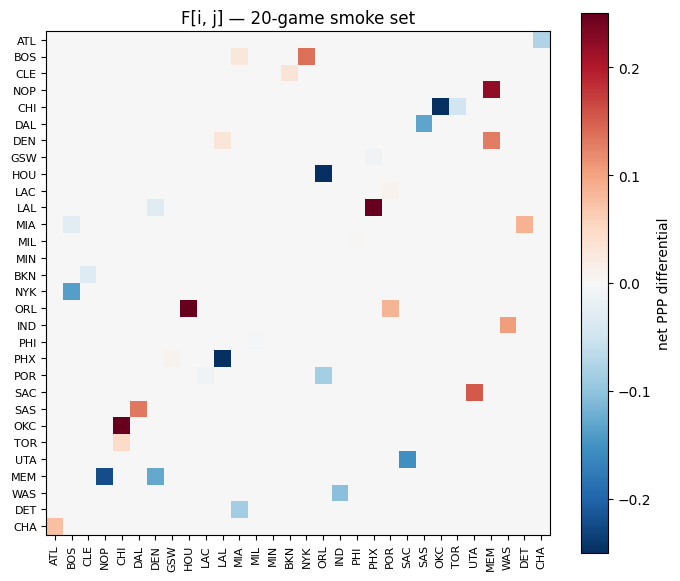

In [12]:
# Heatmap of F restricted to teams that played in our 20-game sample
seen_teams = np.where(ds20.agent_game_mask.any(axis=1))[0]
F_sub = ds20.F[np.ix_(seen_teams, seen_teams)]
names_sub = [ds20.team_names[i] for i in seen_teams]

fig, ax = plt.subplots(figsize=(7, 6), dpi=100)
im = ax.imshow(F_sub, cmap='RdBu_r', vmin=-0.25, vmax=0.25)
ax.set_xticks(range(len(names_sub)))
ax.set_xticklabels(names_sub, rotation=90, fontsize=8)
ax.set_yticks(range(len(names_sub)))
ax.set_yticklabels(names_sub, fontsize=8)
ax.set_title('F[i, j] — 20-game smoke set')
plt.colorbar(im, ax=ax, label='net PPP differential')
plt.tight_layout()
plt.show()


## 7. Mask & padding sanity

The hierarchical encoder uses the masks heavily — every padded slot
must be true zero so attention doesn't latch onto noise.


In [13]:
# Pick the first (team, game_slot) that holds real data
i, g = next(
    (i, g)
    for i in range(len(ds.team_names))
    for g in range(ds.agent_games.shape[1])
    if ds.agent_game_mask[i, g]
)
print(f'Inspecting agent={ds.team_names[i]}, game_slot={g}')
print(f'  valid tokens                  : {int(ds.agent_token_mask[i, g].sum())}')
print(f'  feature sum on real region    : {ds.agent_games[i, g][ds.agent_token_mask[i, g]].sum():.2f}')
print(f'  feature sum on padded region  : {ds.agent_games[i, g][~ds.agent_token_mask[i, g]].sum():.2f}  (must be 0)')

# is_self_offense should average ~0.5 per game (each side has ~half the poss)
is_self_off = ds.agent_games[..., 0]
fractions = (
    (is_self_off * ds.agent_token_mask).sum(-1)
    / ds.agent_token_mask.sum(-1).clip(min=1)
)
real = fractions[ds.agent_game_mask]
print(f'\nis_self_offense fraction across real games : '
      f'mean={real.mean():.3f}, std={real.std():.3f}')


Inspecting agent=NOP, game_slot=0
  valid tokens                  : 201
  feature sum on real region    : 979.53
  feature sum on padded region  : 0.00  (must be 0)

is_self_offense fraction across real games : mean=0.500, std=0.006


## Next steps

To train end-to-end:

```python
from fptajax import hierarchical_skill_fpta, TrainConfig

ds_full = build_nba_dataset(season='2023-24', L_max=260)   # ~12-15 min once, cached

result = hierarchical_skill_fpta(
    agent_games=ds_full.agent_games,
    agent_token_mask=ds_full.agent_token_mask,
    agent_game_mask=ds_full.agent_game_mask,
    F=ds_full.F,
    token_dim=ds_full.token_dim,
    L_max=ds_full.L_max,
    trait_dim=24, d=12, d_model=32, n_layers=1, n_heads=2,
    config=TrainConfig(n_steps=2000, lr=5e-4, batch_size=8),
)
```

Hyperparameters mirror `examples/tennis/train_skill.py` for an
apples-to-apples first comparison.
